In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [4]:

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')


sample_data = [
    ('Pen', 20, 5.0),
    ('Notebook', 10, 15.0),
    ('Pencil', 50, 2.0),
    ('Eraser', 30, 1.5),
    ('Pen', 25, 5.0),
    ('Notebook', 5, 15.0),
    ('Pencil', 40, 2.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()


In [5]:
query = '''
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
'''

df = pd.read_sql_query(query, conn)
print(df)


    product  total_qty  revenue
0    Eraser         30     45.0
1  Notebook         15    225.0
2       Pen         45    225.0
3    Pencil         90    180.0


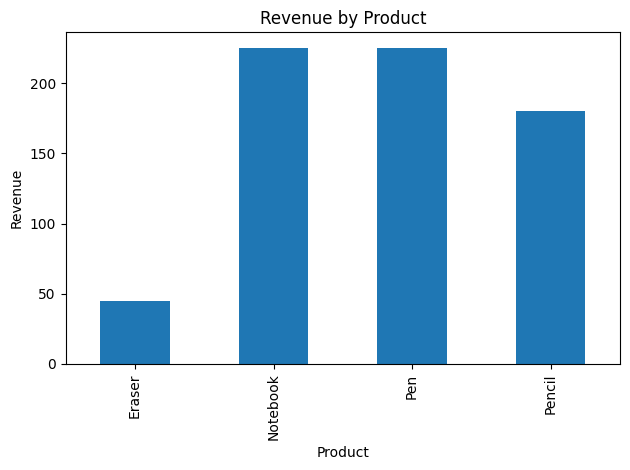

In [6]:
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()


In [7]:
conn.close()
